In [1]:
import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.postprocessing as spost
import spikeinterface.qualitymetrics as sqm
import spikeinterface.comparison as sc
import spikeinterface.exporters as sexp
import spikeinterface.curation as scur
import spikeinterface.widgets as sw
from probeinterface import generate_linear_probe

In [2]:
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

date = "2023-09-26"
round = 1

date_obj = datetime.strptime(date, "%Y-%m-%d")
date_str = date_obj.strftime("%y%m%d")  # → "230926"

# build paths safely
round_folder = f"{date_str}_round{round}"
base_dir = os.path.join(
    "/home/connorlab/Documents/IntanData/Cortana", date, round_folder
)

In [3]:
from analyses.sort_spikes.sort_spikes import get_recording_session_info, compute_device_channel_index

# Read recording
intan_file_directory = base_dir
sampling_frequency, channels = get_recording_session_info(intan_file_directory)
folder_name = os.path.basename(os.path.normpath(intan_file_directory))
print(f"sorting session: {folder_name}")
recording = si.read_binary(os.path.join(intan_file_directory, "amplifier.dat"),
                           sampling_frequency=sampling_frequency, dtype=np.int16,
                           num_channels=len(channels), gain_to_uV=0.195, offset_to_uV=0.0)



probe = generate_linear_probe(num_elec=32, ypitch=65,
                              contact_shapes="circle", contact_shape_params={"radius": 20})
device_channel_idx = compute_device_channel_index(channels)
probe.set_device_channel_indices(device_channel_idx)
recording = recording.set_probe(probe)

# Pre-Processing
recording_f = spre.bandpass_filter(recording, freq_min=300, freq_max=6000)
recording_preprocessed = spre.common_reference(recording_f, reference="global", operator="median")

sorting_KS4 = ss.read_sorter_folder(os.path.join(base_dir, 'kilosort4_output'))
sorting_MS5 = ss.read_sorter_folder(os.path.join(base_dir, 'mountainsort5_output'))
sorting_TDC = ss.read_sorter_folder(os.path.join(base_dir, 'tridesclous_output'))


Reading Intan Technologies RHD2000 Data File, Version 3.2

Found 24 amplifier channels.
Found 0 auxiliary input channels.
Found 0 supply voltage channels.
Found 0 board ADC channels.
Found 2 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.

Header file contains no data.  Amplifiers were sampled at 20.00 kS/s.
Done!  Elapsed time: 0.0 seconds
sorting session: 230926_round1
native_to_reidx {2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10, 14: 11, 17: 12, 18: 13, 19: 14, 20: 15, 21: 16, 22: 17, 24: 18, 25: 19, 26: 20, 27: 21, 28: 22, 29: 23}
Device channel idx: [19, 4, 16, 7, 20, 3, 15, 8, 17, 6, 21, 2, 14, 9, 22, 1, 18, 5, 13, 10, 23, 0, 12, 11, -1, -1, -1, -1, -1, -1, -1, -1]


/home/connorlab/Documents/GitHub/Julie/venv/lib/python3.10/site-packages/spikeinterface/core/baserecordingsnippets.py:150: UserWarning: The given probes have unconnected contacts: they are removed
  warn("The given probes have unconnected contacts: they are removed")
/home/connorlab/Documents/GitHub/Julie/venv/lib/python3.10/site-packages/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(


####
# extract_waveforms() and WaveformExtractor() have been replaced by the `SortingAnalyzer` since version 0.101.0.
# You should use `spikeinterface.create_sorting_analyzer()` instead.
# `spikeinterface.extract_waveforms()` is now mocking the old behavior for backwards compatibility only,
# and may potentially be removed in a future version.
####


estimate_sparsity (no parallelization):   0%|          | 0/2673 [00:00<?, ?it/s]

/home/connorlab/Documents/GitHub/Julie/venv/lib/python3.10/site-packages/spikeinterface/core/basesorting.py:380: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


compute_waveforms (no parallelization):   0%|          | 0/2673 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

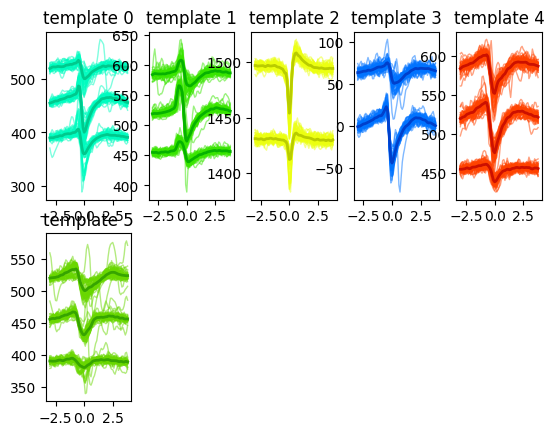

In [5]:
we = si.extract_waveforms(
    recording_preprocessed,
    sorting_TDC,
    folder="waveforms_cache1",
    ms_before=1.5,  # window before spike (ms)
    ms_after=2.0,  # window after spike (ms)
    max_spikes_per_unit=50,  # <-- sample ~50 spikes per unit
    return_scaled=True# plot in physical units (µV) if available
)
some_units = we.sorting.unit_ids[:6]
w = sw.plot_unit_waveforms(
    we,
    unit_ids=some_units,
    max_spikes_per_unit=50,  # subsample for plotting if needed
    same_axis=False  # one axis per unit (easier to scan)
)
plt.show()